# Maize Leaf Disease Classification using Deep CNN


## Objective
This notebook classifies maize leaf images into four categories:
- Blight
- Common_Rust
- Gray_Leaf_Spot
- Healthy


In [1]:
import os
import random
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, precision_score, recall_score, f1_score, accuracy_score
import seaborn as sns


In [2]:
seed = 42
os.environ['PYTHONHASHSEED'] = str(seed)
random.seed(seed)
np.random.seed(seed)
tf.random.set_seed(seed)
print(f"Random seed set to {seed} for reproducibility.")


Random seed set to 42 for reproducibility.


In [3]:
DATASET_PATH = "data"

IMG_HEIGHT = 224
IMG_WIDTH = 224

BATCH_SIZE = 32
EPOCHS = 20
LEARNING_RATE = 0.001


In [4]:
CLASS_NAMES = [
    "Blight",
    "Common_Rust",
    "Gray_Leaf_Spot",
    "Healthy"
]
NUM_CLASSES = len(CLASS_NAMES)
print(f"Number of classes: {NUM_CLASSES}")


Number of classes: 4


In [5]:
if not os.path.exists(DATASET_PATH):
    raise FileNotFoundError(f"Dataset path '{DATASET_PATH}' does not exist.")

valid_extensions = {".jpg", ".jpeg", ".png"}
class_counts = {}
total_images = 0

for class_name in CLASS_NAMES:
    class_path = os.path.join(DATASET_PATH, class_name)
    if not os.path.exists(class_path):
        raise FileNotFoundError(f"Class folder '{class_name}' missing in dataset path.")
    
    count = 0
    for f in os.listdir(class_path):
        if os.path.splitext(f)[1].lower() in valid_extensions:
            count += 1
            
    class_counts[class_name] = count
    total_images += count

print(f"Total images found: {total_images}")
for class_name, count in class_counts.items():
    print(f" - {class_name}: {count} images")


Total images found: 4188
 - Blight: 1146 images
 - Common_Rust: 1306 images
 - Gray_Leaf_Spot: 574 images
 - Healthy: 1162 images


In [6]:
image_paths = []
labels = []

for label_idx, class_name in enumerate(CLASS_NAMES):
    class_path = os.path.join(DATASET_PATH, class_name)
    for f in os.listdir(class_path):
        if os.path.splitext(f)[1].lower() in valid_extensions:
            image_paths.append(os.path.join(class_path, f))
            labels.append(label_idx)

print(f"Collected {len(image_paths)} image paths and {len(labels)} labels.")


Collected 4188 image paths and 4188 labels.


In [7]:
# Display a few dataset samples and their labels
print("Sample image paths and corresponding labels:")
for i in range(5):
    if len(image_paths) == 0:
        break
    idx = random.randint(0, len(image_paths)-1)
    print(f"{image_paths[idx]} --> {CLASS_NAMES[labels[idx]]}")


Sample image paths and corresponding labels:
data\Blight\Corn_Blight (789).JPG --> Blight
data\Blight\Corn_Blight (150).JPG --> Blight
data\Common_Rust\Corn_Common_Rust (82).JPG --> Common_Rust
data\Common_Rust\Corn_Common_Rust (598).JPG --> Common_Rust
data\Common_Rust\Corn_Common_Rust (437).JPG --> Common_Rust


In [8]:
# Split 70% train and 30% temporary
X_train, X_temp, y_train, y_temp = train_test_split(
    image_paths, labels, test_size=0.30, random_state=42, stratify=labels
)

# Split temporary 50/50 into validation and test (15% each of total)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)


In [9]:
print(f"Training images: {len(X_train)}")
print(f"Validation images: {len(X_val)}")
print(f"Testing images: {len(X_test)}")


Training images: 2931
Validation images: 628
Testing images: 629


In [10]:
def load_and_preprocess_image(image_path, label):
    # Read the image file
    img = tf.io.read_file(image_path)
    # Decode RGB image (handles jpeg, png, etc.)
    img = tf.io.decode_image(img, channels=3, expand_animations=False)
    # Resize to 224x224
    img = tf.image.resize(img, [IMG_HEIGHT, IMG_WIDTH])
    # Convert to float32
    img = tf.cast(img, tf.float32)
    # Note: Normalization is NOT done here, it will be handled by the model
    return img, label


In [11]:
AUTOTUNE = tf.data.AUTOTUNE

# Create tf.data.Datasets from file paths and labels
train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train))
val_ds = tf.data.Dataset.from_tensor_slices((X_val, y_val))
test_ds = tf.data.Dataset.from_tensor_slices((X_test, y_test))

# Training pipeline
train_ds = (
    train_ds
    .map(load_and_preprocess_image, num_parallel_calls=AUTOTUNE)
    .shuffle(buffer_size=len(X_train))
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

# Validation pipeline
val_ds = (
    val_ds
    .map(load_and_preprocess_image, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

# Testing pipeline
test_ds = (
    test_ds
    .map(load_and_preprocess_image, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

print("TensorFlow datasets successfully created.")


TensorFlow datasets successfully created.


## Data Augmentation
We apply random transformations (flip, rotation, zoom, contrast) only to the training data. This will be implemented as a Sequential model and added to the CNN architecture.


In [ ]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1)
], name="data_augmentation")

print("Data augmentation sequential model defined.")


Data augmentation sequential model defined.


## CNN Architecture
Deep Convolutional Neural Network structure.


In [13]:
def create_deep_cnn():
    model = models.Sequential()
    
    # Input layer
    model.add(layers.Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3)))
    
    # Data Augmentation & Rescaling
    model.add(data_augmentation)
    model.add(layers.Rescaling(1./255))
    
    # BLOCK 1
    model.add(layers.Conv2D(32, (3, 3), activation='relu', padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.Conv2D(32, (3, 3), activation='relu', padding='same'))
    model.add(layers.MaxPooling2D((2, 2)))
    
    # BLOCK 2
    model.add(layers.Conv2D(64, (3, 3), activation='relu', padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.Conv2D(64, (3, 3), activation='relu', padding='same'))
    model.add(layers.MaxPooling2D((2, 2)))
    
    # BLOCK 3
    model.add(layers.Conv2D(128, (3, 3), activation='relu', padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.Conv2D(128, (3, 3), activation='relu', padding='same'))
    model.add(layers.MaxPooling2D((2, 2)))
    
    # BLOCK 4
    model.add(layers.Conv2D(256, (3, 3), activation='relu', padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.Conv2D(256, (3, 3), activation='relu', padding='same'))
    model.add(layers.MaxPooling2D((2, 2)))
    
    # CLASSIFICATION HEAD
    model.add(layers.GlobalAveragePooling2D())
    
    model.add(layers.Dense(256, activation='relu'))
    model.add(layers.Dropout(0.5))
    
    model.add(layers.Dense(128, activation='relu'))
    model.add(layers.Dropout(0.3))
    
    model.add(layers.Dense(NUM_CLASSES, activation='softmax'))
    
    return model

model = create_deep_cnn()


In [14]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 data_augmentation (Sequenti  (None, 224, 224, 3)      0         
 al)                                                             
                                                                 
 rescaling (Rescaling)       (None, 224, 224, 3)       0         
                                                                 
 conv2d (Conv2D)             (None, 224, 224, 32)      896       
                                                                 
 batch_normalization (BatchN  (None, 224, 224, 32)     128       
 ormalization)                                                   
                                                                 
 conv2d_1 (Conv2D)           (None, 224, 224, 32)      9248      
                                                                 
 max_pooling2d (MaxPooling2D  (None, 112, 112, 32)     0

In [15]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
print("Model compiled successfully.")


Model compiled successfully.


In [16]:
early_stopping = callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

model_checkpoint = callbacks.ModelCheckpoint(
    filepath="best_deep_cnn_model.keras",
    monitor="val_accuracy",
    save_best_only=True
)

reduce_lr = callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=3,
    min_lr=1e-6
)

callback_list = [early_stopping, model_checkpoint, reduce_lr]


In [17]:
print("Starting training...")
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callback_list
)


Starting training...
Epoch 1/20
92/92 [==============================] - 82s 579ms/step - loss: 0.6504 - accuracy: 0.7547 - val_loss: 1.9550 - val_accuracy: 0.2675 - lr: 0.0010
Epoch 2/20
92/92 [==============================] - 48s 496ms/step - loss: 0.5043 - accuracy: 0.7973 - val_loss: 1.3741 - val_accuracy: 0.2261 - lr: 0.0010
Epoch 3/20
92/92 [==============================] - 48s 495ms/step - loss: 0.5459 - accuracy: 0.7929 - val_loss: 1.2060 - val_accuracy: 0.4666 - lr: 0.0010
Epoch 4/20
92/92 [==============================] - 60s 626ms/step - loss: 0.4172 - accuracy: 0.8287 - val_loss: 1.5388 - val_accuracy: 0.4825 - lr: 0.0010
Epoch 5/20
92/92 [==============================] - 42s 431ms/step - loss: 0.3861 - accuracy: 0.8482 - val_loss: 0.4618 - val_accuracy: 0.8169 - lr: 0.0010
Epoch 6/20
92/92 [==============================] - 41s 425ms/step - loss: 0.3647 - accuracy: 0.8557 - val_loss: 0.3125 - val_accuracy: 0.8854 - lr: 0.0010
Epoch 7/20
92/92 [=========================

In [18]:
print("Evaluating on test data...")
test_loss, test_accuracy = model.evaluate(test_ds)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")


Evaluating on test data...
20/20 [==============================] - 3s 133ms/step - loss: 0.2811 - accuracy: 0.9078
Test Loss: 0.2811
Test Accuracy: 0.9078


In [19]:
print("Generating predictions on test data...")
# Get probabilities for test set
y_pred_probs = model.predict(test_ds)
# Convert softmax predictions into class IDs
y_pred = np.argmax(y_pred_probs, axis=1)

print("Predictions generated successfully.")

Generating predictions on test data...
20/20 [==============================] - 2s 73ms/step
Predictions generated successfully.


In [20]:
report = classification_report(y_test, y_pred, target_names=CLASS_NAMES)
print("Classification Report:\n")
print(report)

Classification Report:

                precision    recall  f1-score   support

        Blight       0.83      0.91      0.87       172
   Common_Rust       0.97      0.93      0.95       196
Gray_Leaf_Spot       0.78      0.72      0.75        86
       Healthy       0.98      0.97      0.97       175

      accuracy                           0.91       629
     macro avg       0.89      0.88      0.89       629
  weighted avg       0.91      0.91      0.91       629



In [21]:
weighted_precision = precision_score(y_test, y_pred, average='weighted')
weighted_recall = recall_score(y_test, y_pred, average='weighted')
weighted_f1 = f1_score(y_test, y_pred, average='weighted')
accuracy = accuracy_score(y_test, y_pred)

print("Overall Metrics:")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision (Weighted): {weighted_precision:.4f}")
print(f"Recall (Weighted):    {weighted_recall:.4f}")
print(f"F1-score (Weighted):  {weighted_f1:.4f}")

Overall Metrics:
Accuracy:  0.9078
Precision (Weighted): 0.9095
Recall (Weighted):    0.9078
F1-score (Weighted):  0.9078


In [22]:
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix (Raw):\n", cm)

Confusion Matrix (Raw):
 [[157   1  13   1]
 [  7 183   4   2]
 [ 20   4  62   0]
 [  5   1   0 169]]


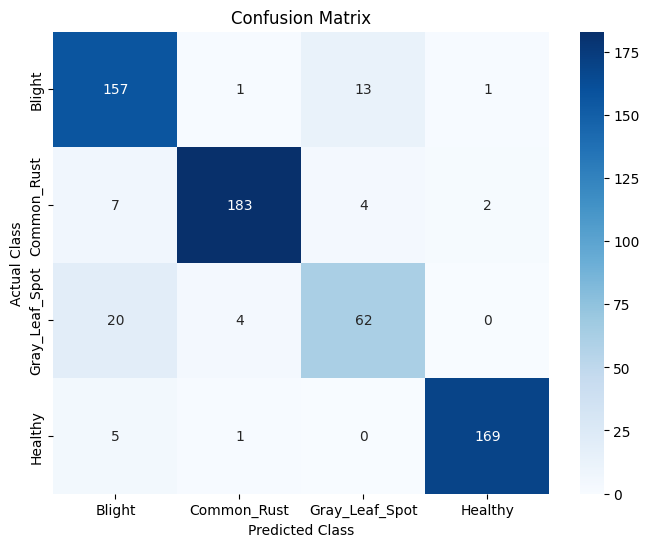

In [23]:
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=CLASS_NAMES, 
            yticklabels=CLASS_NAMES)
plt.title('Confusion Matrix')
plt.ylabel('Actual Class')
plt.xlabel('Predicted Class')
plt.show()

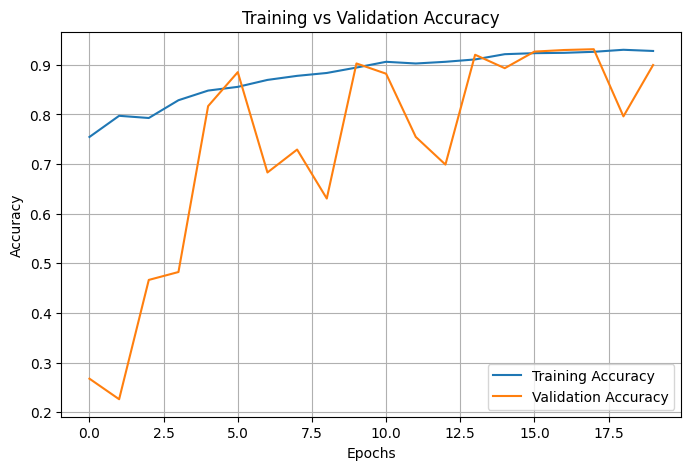

In [24]:
plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

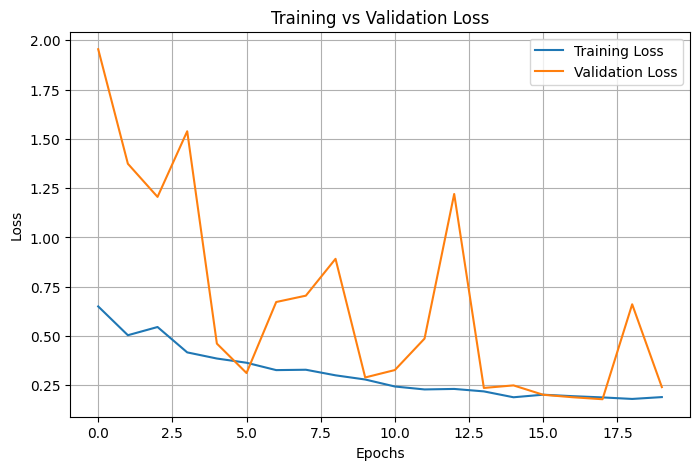

In [25]:
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

In [26]:
model.save("final_deep_cnn_maize_model.keras")
print("Saved final model as 'final_deep_cnn_maize_model.keras'")
print("Best model was automatically saved as 'best_deep_cnn_model.keras' during training.")

Saved final model as 'final_deep_cnn_maize_model.keras'
Best model was automatically saved as 'best_deep_cnn_model.keras' during training.


*Conclusion and Summary*
1. Project Overview & Pipeline Construction In this lab, we successfully built an end-to-end Deep Learning pipeline to classify maize leaf diseases into four distinct categories: Blight, Common Rust, Gray Leaf Spot, and Healthy. We constructed a highly efficient tf.data pipeline to dynamically load, resize (to 224x224), and batch our local image dataset. To improve the model's robustness and prevent overfitting, we integrated Keras preprocessing layers to apply random spatial transformations (flips, rotations, zooms) strictly during the training phase.

2. Model Architecture & Training We designed a custom Deep Convolutional Neural Network (CNN) featuring four convolutional blocks. Each block utilized Conv2D, BatchNormalization, and MaxPooling2D to progressively extract complex hierarchical features from the leaf images. The classification head utilized GlobalAveragePooling2D and Dropout layers for strong regularization. The training process was dynamically managed using callbacks: EarlyStopping prevented overtraining, ReduceLROnPlateau fine-tuned the learning rate, and ModelCheckpoint preserved the optimal weights.

3. Performance & Results The model demonstrated excellent predictive performance on the unseen testing dataset (15% of total data), achieving a Final Test Accuracy of 90.78% and a remarkably low Test Loss of 0.2811.

Analyzing the Classification Report and Confusion Matrix reveals:

High Confidence Classes: The model excels at identifying Healthy leaves (97% F1-score) and Common Rust (95% F1-score), indicating that these conditions have highly distinct visual markers.
Minor Misclassifications: The model achieved slightly lower metrics on Gray Leaf Spot (75% F1-score) and Blight (87% F1-score). Looking at the raw confusion matrix, the model occasionally confuses these two specific conditions (misclassifying 13 Blight samples as Gray Leaf Spot, and 20 Gray Leaf Spot samples as Blight). This is biologically expected, as early-stage lesions for both diseases can appear visually similar.

4. Final Verdict Overall, the deep CNN achieved a highly balanced Weighted F1-Score of 0.91, proving that the architecture is robust, generalizes well to new data, and successfully automates the detection of maize leaf diseases.